<a href="https://colab.research.google.com/github/MayaUA21/TUGAS-AKHIR-MAYA/blob/main/Run%201%20(Non-CLAHE)/Patience%2010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RESIZE GAMBAR

In [ ]:
from PIL import Image
import os

input_folder = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Datasets/Normal'
output_folder = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Resized/Normal'
os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):
    if filename.endswith('.png'):
        img = Image.open(os.path.join(input_folder, filename))
        img = img.resize((224, 224))
        img.save(os.path.join(output_folder, filename))

print("Selesai.")

Selesai.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Contrast Limited Adaptive Histogram Equalization

In [ ]:
!pip install opencv-python

In [ ]:
!pip install matplotlib

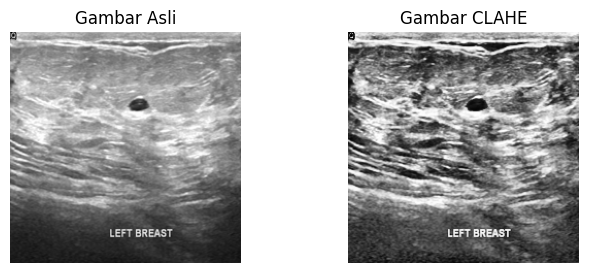

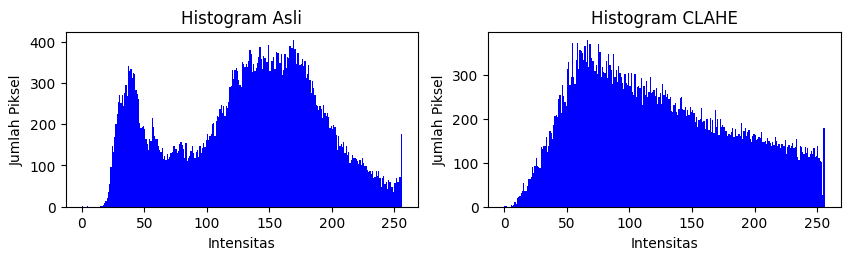

False

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Baca gambar
img = cv2.imread('/content/drive/MyDrive/TUGAS AKHIR MAYA/Resized/Benign/Benign (1).png', cv2.IMREAD_GRAYSCALE)

# Buat objek CLAHE
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(6,6))

# Terapkan CLAHE
clahe_img = clahe.apply(img)

# Gambar asli
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.title('Gambar Asli')
plt.imshow(img, cmap='gray')
plt.axis('off')

# Gambar hasil CLAHE
plt.subplot(1,2,2)
plt.title('Gambar CLAHE')
plt.imshow(clahe_img, cmap='gray')
plt.axis('off')
plt.show()

# Histogram gambar asli
plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
plt.title('Histogram Asli')
plt.hist(img.ravel(), bins=30, range=[0,256], color='blue')
plt.xlabel('Intensitas Warna')
plt.ylabel('Frekuensi')

# Histogram CLAHE
plt.subplot(2,2,2)
plt.title('Histogram CLAHE')
plt.hist(clahe_img.ravel(), bins=256, range=[0,256], color='blue')
plt.xlabel('Intensitas Warna')
plt.ylabel('Frekuensi')
plt.show()

cv2.imwrite('/content/drive/MyDrive/TUGAS AKHIR MAYA/CLAHE/6x6/Benign(1)/(3, 6x6).png', clahe_img)

Pembagian Dataset

In [ ]:
import os
import shutil
import random

folder_sumber = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Resized'
folder_hasil = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Pembagian datasets/Non-CLAHE'
os.makedirs(folder_hasil, exist_ok=True)

# RASIO PEMBAGIAN DATA

rasio_train = 0.70
rasio_val = 0.15
rasio_test = 0.15

# Nama kelas
kelas = ['Benign', 'Malignant', 'Normal']

# MEMBUAT FOLDER TRAIN VAL TEST

for bagian in ['train', 'val', 'test']:
    for nama_kelas in kelas:
        folder_tujuan = os.path.join(
            folder_hasil,
            bagian,
            nama_kelas
        )

        os.makedirs(folder_tujuan, exist_ok=True)

# PROSES PEMBAGIAN DATA

for nama_kelas in kelas:

    # Lokasi folder tiap kelas
    folder_kelas = os.path.join(
        folder_sumber,
        nama_kelas
    )

    # Mengambil semua gambar
    images = [
        f for f in os.listdir(folder_kelas)
        if os.path.isfile(os.path.join(folder_kelas, f))
    ]

    random.shuffle(images)
    total = len(images)
    jumlah_train = int(total * rasio_train)
    jumlah_val = int(total * rasio_val)

    # Pembagian dataset
    train_images = images[:jumlah_train]
    val_images = images[jumlah_train : jumlah_train + jumlah_val]
    test_images = images[jumlah_train + jumlah_val :]

    # MENYIMPAN GAMBAR KE FOLDER
    pembagian = {
        'train': train_images,
        'val': val_images,
        'test': test_images
    }

    for bagian, daftar_images in pembagian.items():
        folder_tujuan = os.path.join(folder_hasil, bagian, nama_kelas)
        for nama_file in daftar_images:
            sumber_file = os.path.join(folder_kelas, nama_file)
            tujuan_file = os.path.join(folder_tujuan, nama_file)
            shutil.copy2(sumber_file, tujuan_file)

print("Dataset berhasil dibagi menjadi train, val, dan test!")

Dataset berhasil dibagi menjadi train, val, dan test!


In [ ]:
from tensorflow.keras import backend as K
K.clear_session()

Deep Learning (1 tile size)

Found 210 images belonging to 3 classes.
Found 45 images belonging to 3 classes.


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

...


Epoch 2: finished saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5
7/7 - 17s - 2s/step - accuracy: 0.7619 - loss: 0.5896 - val_accuracy: 0.7556 - val_loss: 0.6824
Epoch 3/100

Epoch 3: val_loss improved from 0.68237 to 0.66465, saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5
7/7 - 21s - 3s/step - accuracy: 0.7762 - loss: 0.5152 - val_accuracy: 0.7556 - val_loss: 0.6647
Epoch 4/100

Epoch 4: val_loss improved from 0.66465 to 0.57131, saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5
7/7 - 24s - 3s/step - accuracy: 0.8571 - loss: 0.4161 - val_accuracy: 0.7556 - val_loss: 0.5713
Epoch 5/100

Epoch 5: val_loss improved from 0.57131 to 0.51657, saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5
7/7 - 35s - 5s/step - accuracy: 0.8952 - loss: 0.2889 - val_accuracy: 0.8222 - val_loss: 0.5166
Epoch 6/100

Epoch 6: val_loss improved from 0.51657 to 0.48248, saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5



Epoch 6: finished saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5
7/7 - 18s - 3s/step - accuracy: 0.9143 - loss: 0.2297 - val_accuracy: 0.8000 - val_loss: 0.4825
Epoch 7/100

Epoch 7: val_loss did not improve from 0.48248
7/7 - 16s - 2s/step - accuracy: 0.9000 - loss: 0.2565 - val_accuracy: 0.8000 - val_loss: 0.4909
Epoch 8/100

Epoch 8: val_loss did not improve from 0.48248
7/7 - 16s - 2s/step - accuracy: 0.9095 - loss: 0.2267 - val_accuracy: 0.8222 - val_loss: 0.5208
Epoch 9/100

Epoch 9: val_loss did not improve from 0.48248
7/7 - 16s - 2s/step - accuracy: 0.9476 - loss: 0.1821 - val_accuracy: 0.7778 - val_loss: 0.5434
Epoch 10/100

Epoch 10: val_loss did not improve from 0.48248
7/7 - 16s - 2s/step - accuracy: 0.9381 - loss: 0.1983 - val_accuracy: 0.7778 - val_loss: 0.5495
Epoch 11/100

Epoch 11: val_loss did not improve from 0.48248
7/7 - 20s - 3s/step - accuracy: 0.9333 - loss: 0.1751 - val_accuracy: 0.7778 - val_loss: 0.5540
Epoch 12/10

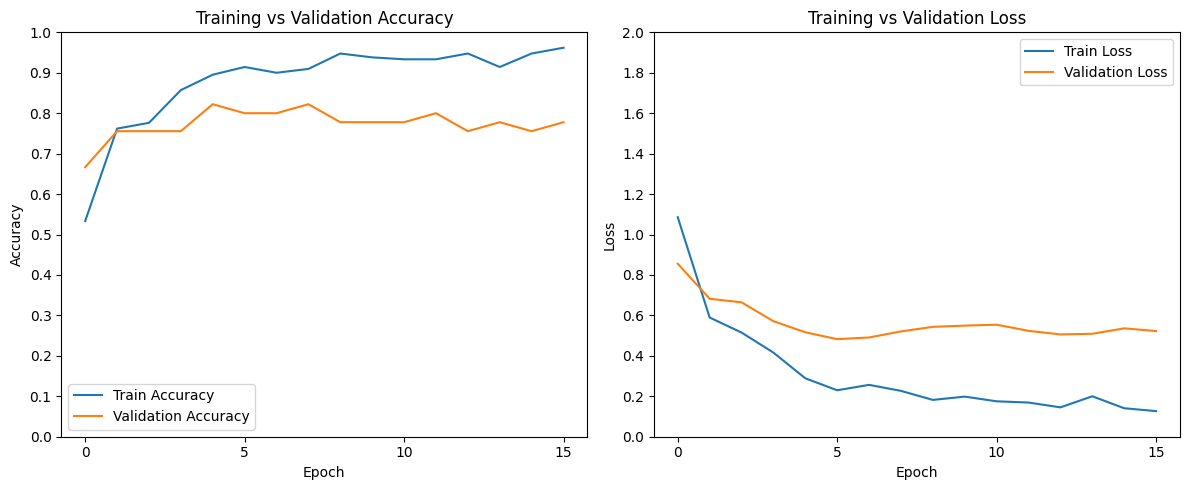

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# PATH DATASET
train_path = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Pembagian datasets/Non-CLAHE/train'
val_path = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Pembagian datasets/Non-CLAHE/val'

# AUGMENTASI
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range= 0.05,
    height_shift_range= 0.05,
    zoom_range= 0.1,
    horizontal_flip= True,
    vertical_flip= False,
    fill_mode= 'nearest')

#VALIDASI HANYA RESCALE
val_datagen = ImageDataGenerator(
    rescale=1./255
)

#LOAD DATA
train_data = datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# MOBILENETV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.summary()

# Bekukan layer base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
output = Dense(
    train_data.num_classes,
    activation='softmax'
)(x)

model = Model(inputs=base_model.input, outputs=output)

# KOMPILASI MODEL
model.compile(
    optimizer= Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# MENYIMPAN MODEL TERBAIK
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# TRAINING
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=[checkpoint, early_stop],
    verbose=2
)

# TABEL AKURASI DAN LOSS
Table = pd.DataFrame({
    'Epoch': range(1, len(history.history['accuracy']) + 1),
    'Train_Accuracy': history.history['accuracy'],
    'Val_Accuracy': history.history['val_accuracy'],
    'Train_Loss': history.history['loss'],
    'Val_Loss': history.history['val_loss']
})

print("\n=== TABEL AKURASI DAN LOSS PER EPOCH ===")
print(Table.to_string(index=False))

# PLOT GRAFIK AKURASI DAN LOSS
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(np.arange(0, len(history.history['accuracy'])+1, 5))     # Sumbu X: 0,5,10,...
plt.yticks(np.arange(0, 1.1, 0.1))             # Sumbu Y: 0.0,0.1,...,1.0
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(np.arange(0, len(history.history['loss'])+1, 5))     # Sumbu X: 0,5,10,...
plt.yticks(np.arange(0, 2.1, 0.2))
plt.legend()
plt.tight_layout()

plt.show()

CONFUSION MATRIK

Found 45 images belonging to 3 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step


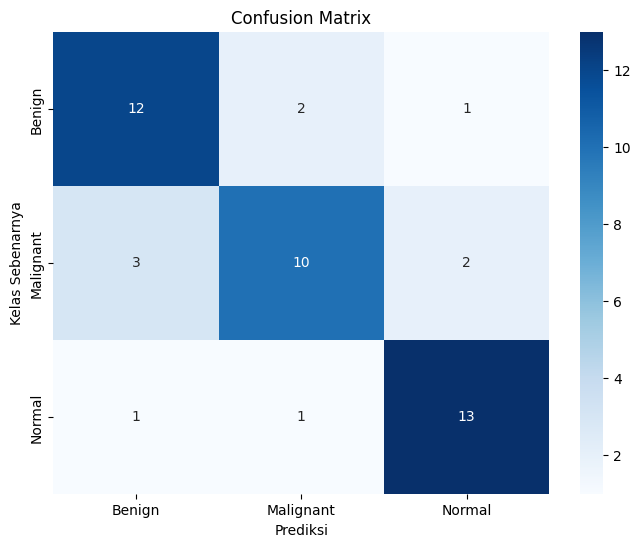


 Laporan Evaluasi Model:
              precision    recall  f1-score   support

      Benign       0.75      0.80      0.77        15
   Malignant       0.77      0.67      0.71        15
      Normal       0.81      0.87      0.84        15

    accuracy                           0.78        45
   macro avg       0.78      0.78      0.78        45
weighted avg       0.78      0.78      0.78        45


 Akurasi Total: 0.7778


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

model_hasil = '/content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5'
model = load_model(model_hasil)

data_path = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Pembagian datasets/Non-CLAHE/test'

eval_datagen = ImageDataGenerator(rescale=1./255)

train_eval = eval_datagen.flow_from_directory(
    data_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   #
)

#Prediksi
y_pred = model.predict(train_eval)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = train_eval.classes
class_labels = list(train_eval.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Kelas Sebenarnya')
plt.show()

# Laporan Evaluasi
print("\n Laporan Evaluasi Model:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Akurasi Total
acc = accuracy_score(y_true, y_pred_classes)
print(f"\n Akurasi Total: {acc:.4f}")